# Exploratory Data Analysis

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_additional = pd.read_csv('data/Rainfall.csv') 

In [3]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [4]:
train = df_train.copy()
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


- 2190 observations
- we removed columns 'id' and 'day' from the data as they are not useful for the model
- we will use the 'rainfall' column as the target variable

In [6]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']
target = 'rainfall'

# Info about datset

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       2190 non-null   float64
 1   maxtemp        2190 non-null   float64
 2   temparature    2190 non-null   float64
 3   mintemp        2190 non-null   float64
 4   dewpoint       2190 non-null   float64
 5   humidity       2190 non-null   float64
 6   cloud          2190 non-null   float64
 7   sunshine       2190 non-null   float64
 8   winddirection  2190 non-null   float64
 9   windspeed      2190 non-null   float64
 10  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 188.3 KB


- no missing values
- only numerical columns (target is int, others float)

In [54]:
X_train.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703
std,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659
min,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000
25%,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000
50%,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000
75%,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000
max,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000


### Info about target

In [10]:
train['rainfall'].describe()

count    2190.000000
mean        0.753425
std         0.431116
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: rainfall, dtype: float64

In [11]:
train['rainfall'].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

- target variable is imbalanced - 1s are 3 times more than 0s

## Correlation

<Axes: >

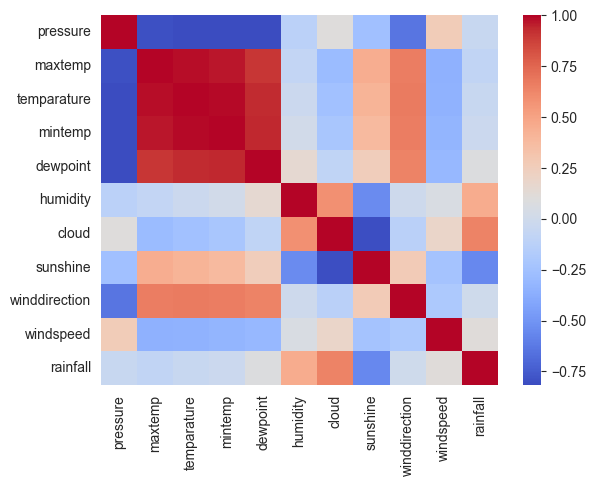

In [55]:
corr = train.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')

- clear negative correlation beetwen 'sunshine' and target variable
- big candidates for removal: 'maxtemp', 'mintemp', 'temperature' , 'dewpoint' (reasonable to leave only one of them - probably 'temperature' or 'dewpoint')

#### Importance of variables - model

In [58]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending=False)
print(feature_importance)

         Feature  Importance
6          cloud    0.469018
7       sunshine    0.082561
9      windspeed    0.074572
4       dewpoint    0.066069
0       pressure    0.060101
5       humidity    0.059160
1        maxtemp    0.057619
3        mintemp    0.051024
8  winddirection    0.040841
2    temparature    0.039035


We got more information about importance of variables, so we can have more information about which variables we can maybe remove.

## Distribution of variables

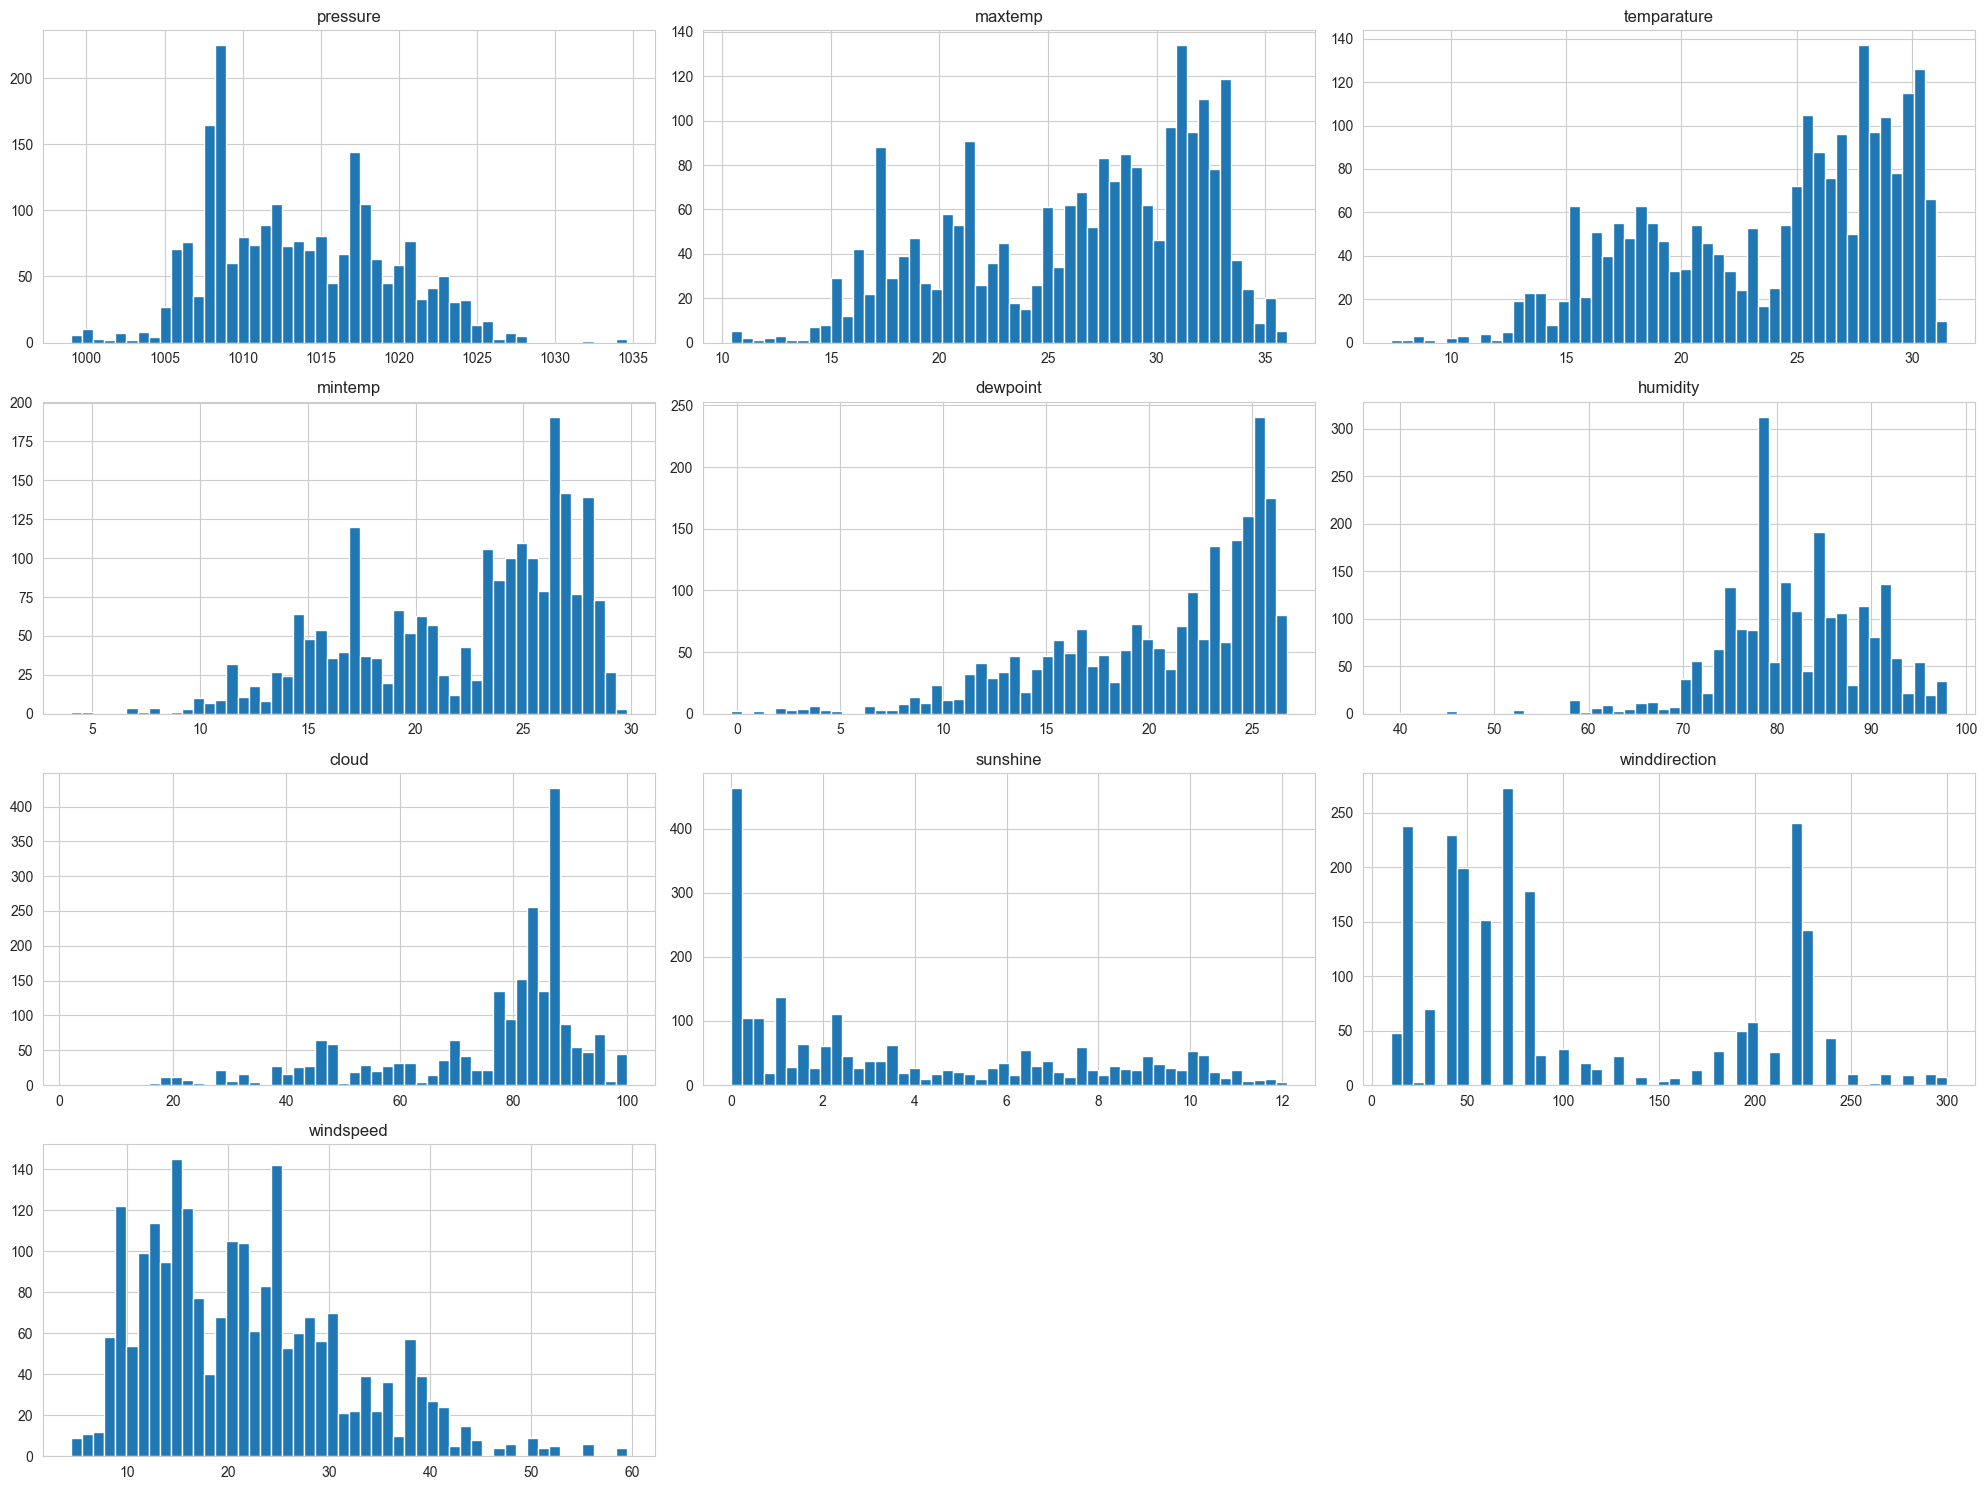

In [31]:
X_train.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

## Outliers

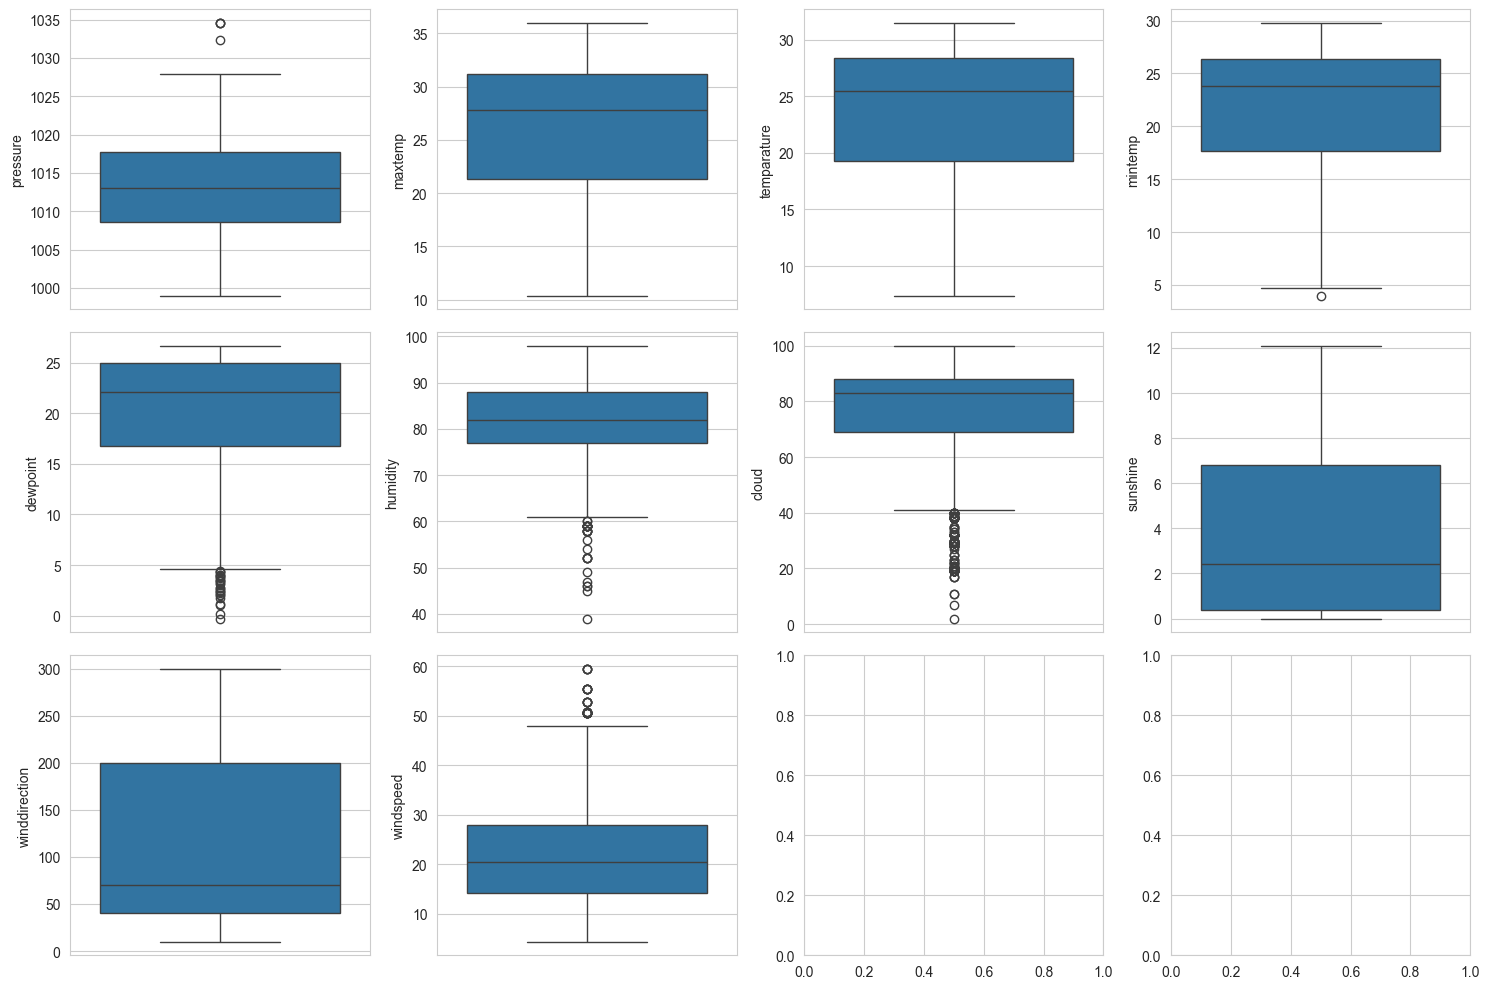

In [53]:
fig, axs = plt.subplots(3, 4, figsize=(15,10))
axs = axs.flatten()
for i in X_train.columns:
    sns.boxplot(X_train[i], ax= axs[X_train.columns.get_loc(i)])
plt.tight_layout()
plt.show()

It looks like there aren't many outliers in the dataset, some appear only in 'pressure', 'humidity', 'cloud' and 'windspeed' columns
